In [ ]:
!pip install gymnasium==1.2.3
!pip install stable-baselines3==2.7.1

In [ ]:
import collections
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import stable_baselines3 as sb3


print("gymnasium:", gym.__version__)
print("matplotlib:", matplotlib.__version__)
print("numpy:", np.__version__)
print("pytorch:", torch.__version__)
print("stable baselines3:", sb3.__version__)

gymnasium: 1.2.3
matplotlib: 3.10.0
numpy: 2.0.2
pytorch: 2.10.0+cu128
stable baselines3: 2.7.1


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
class MyInventoryEnv(gym.Env):
    def __init__(self, continuous_action_flag, initial_inventory, max_step, lead_time):
        super().__init__()
        # ステップ数をカウントするため
        self.current_step = 0
        # 行動が連続的かどうか(違う場合は離散的)のフラグ
        self.continuous_action_flag = continuous_action_flag
        # 1エピソードの最大ステップ数
        self.max_step = max_step
        # 発注から納品までのリードタイム
        self.lead_time = lead_time
        # 納品待ち数を保存するキュー # 初期値は[0, 0]とする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # 行動(変数名はself.action_spaceがお作法)を定義
        if self.continuous_action_flag:  # 行動は連続値
            self.action_space = gym.spaces.Box(low=0,  # 発注量0～10を行動として、array形状を(1, )とする
                                               high=10,
                                               shape=(1, ),
                                               dtype=np.float32)
        else:  # 行動は離散値
            self.action_space = gym.spaces.Discrete(n=11,  # 発注量は0から11個の離散値で0～10の行動となる # array形状は( )でint扱いになる
                                                    seed=42,
                                                    start=0,
                                                    dtype=np.int32)
        # 状態(変数名はself.observation_spaceがお作法)を定義
        self.observation_space = gym.spaces.Box(low=0,  # 在庫数と納品待ち数(翌日と翌々日)として0～50の値で、array形状を(3, )とする
                                                high=50,
                                                shape=(1+self.lead_time, ),
                                                dtype=np.float32)
        # 状態の初期値を定義して、状態を定義する
        self.initial_state = np.array([initial_inventory]+list(self.delivery_queue),
                                      dtype=np.float32)
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # 状態を初期状態にする
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # キューを初期値にする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time, maxlen=self.lead_time)
        # お作法としてinfo用の変数を作成する
        info = {}
        # ステップ数もリセットする
        self.current_step = 0
        # 初期状態とinfoを戻す
        return self.state, info

    def step(self, action):  # gymのお作法としてstep関数の引数はactionのみとする
        # ステップ数を+1する
        self.current_step = self.current_step + 1
        # 行動が連続値の時は整数部分を取得、離散値の時はそのまま
        if self.continuous_action_flag:
            preprocessed_action = np.round(a=action[0],  # 形状は(1, )なので[0]で要素を取得して四捨五入する
                                           decimals=0)
        else:
            preprocessed_action = int(action)  # そのまま(念のためint型にする)
        # 前々日に発注した数を納品する(キューの前から1つ取り出す)
        arrived_item = self.delivery_queue.popleft()
        # 需要は期待値が3のポアソン分布からサンプリングする
        demand = np.random.poisson(lam=3,
                                   size=(1, ))
        # サンプリングした需要と、納品数を踏まえて、在庫量を更新する
        inventory = np.clip(a=self.state[0] - demand[0] + arrived_item,
                            a_min=0,  # 在庫量はマイナスにはならない
                            a_max=50,  # 在庫量はself.observation_stateで定義したhigh=50を超えないようにするため
                            dtype=np.float32)
        # 行動(発注量)をキューの後ろに保存する
        self.delivery_queue.append(preprocessed_action)
        # 状態(在庫量と納品待ち数)を更新する
        self.state = np.array([inventory]+list(self.delivery_queue),
                              dtype=np.float32)
        # 在庫数15を基準として報酬を設定する # 在庫数15付近を保つように行動するようになると思う
        delta = abs(self.state[0] - 15)
        if 0 < delta < 5:
            reward = 1.0
        elif 5 <= delta < 10:
            reward = 0
        else:
            reward = - (delta * 0.1)
        # 発注を行う場合は発注コスト発生として報酬を減らす # ポアソン分布の期待値3の需要を見破られて発注を定期的に3にする事を防ぐ
        if preprocessed_action != 0:
            reward = reward - 0.5
        # 在庫量が0になった場合は在庫管理が適切でなかったとしてterminatedをtrueにする
        if self.state[0] == 0:
            terminated = True
        else:
            terminated = False
        # ステップ数が最大ステップ数になったらtruncatedをtrueにする
        if self.current_step == self.max_step:
            truncated = True
        else:
            truncated = False
        # お作法としてinfoを用意する
        info = {}
        # 状態、報酬、terminated、truncated、infoの並びで戻す
        return self.state, reward, terminated, truncated, info

PPOは状態価値に注目<br>(actorの目的関数は「確率比率×アドバンテージ」でアドバンテージはcriticの結果を踏まえて算出)

In [ ]:
env_ppo = MyInventoryEnv(continuous_action_flag=False,  # PPOは離散的な行動を対象とする
                         initial_inventory=20,
                         max_step=31,
                         lead_time=2)
model_ppo = sb3.PPO(policy="MlpPolicy",
                    env=env_ppo,
                    learning_rate=0.001,
                    n_steps=2048,  # バッファに保存するステップ数 # エピソード完了した際はそのまま次のエピソードが開始されて指定のステップ数まで保存される
                    batch_size=64,  # 学習時のミニバッチ数 # n_stepsで割り切れる値がテンソルの形状的にキレイ
                    n_epochs=10,  # バッファのデータを使って何回ActorとCriticを学習するか
                    gamma=0.98,  # TD法やモンテカルロ法で価値を算出する際の割引率
                    gae_lambda=0.95,  # Actorの目的関数に用いるアドバンテージ(A=Q-V)とみなすGAE(割引率とλを使ってTD法を積み重ねる)を算出する際のモンテカルロの割合(0ならばTD法、1ならばモンテカルロ法)
                    clip_range=0.2,  # Actorの損失値を求める際の新旧Actorの確率比率のクリッピング幅(0.2ならば0.8～1.2になる)
                    verbose=1,  # 学習時にn_steps数毎に出力するログの詳細具合
                    device=DEVICE)
model_ppo.learn(total_timesteps=102400,  # 学習に用いるデータのステップ数 # n_steps数 × バッファを更新する回数
                progress_bar=True)

SACは行動価値に注目<br>(actorの目的関数は「critic推論価値＋重み付きエントロピー尺度」)

In [ ]:
env_sac = MyInventoryEnv(continuous_action_flag=True,  # SACは連続的な行動を対象とする
                         initial_inventory=20,
                         max_step=31,
                         lead_time=2)
# https://stable-baselines3.readthedocs.io/en/master/modules/sac.html
model_sac = sb3.SAC(policy="MlpPolicy",
                    env=env_sac,
                    learning_rate=0.0003,
                    buffer_size=2048,  # 経験バッファに保存するステップ数
                    learning_starts=64,  # 学習を開始する経験バッファ保存ステップ数
                    batch_size=64,
                    tau=0.005,  # ターゲットcriticのパラメータ更新を、criticのパラメータで行う割合
                    gamma=0.98,  # critic学習で正解データとなるターゲットQを算出する際の割引率
                    train_freq=1,  # 経験バッファにlearning_startsステップ数保存されて以降、何ステップ毎にactorとcriticの学習を行うか
                    ent_coef="auto",  # actor学習での損失値の算出や、critic学習でのターゲットQの算出にて、actorの推論による方策のエントロピー(ランダム性の尺度:−logπ(a∣s))を盛り込む割合(autoだと学習して動的な値になる)
                    target_update_interval=1,  # criticのパラメータ更新に伴って、ターゲットcriticを更新する間隔(1ならばcriticを学習するとターゲットcriticも学習する)
                    verbose=1,
                    device=DEVICE)
model_sac.learn(total_timesteps=102400,
                progress_bar=True)

In [ ]:
def inference_timestep(algorithm_name, env, model, timestep):
    state, _ = env.reset()
    total_reward = 0
    inventory_list = []
    available_inventory_list = []
    for i in range(timestep):
        print("{a}:{b}ステップ: 在庫量:{c} 翌納品:{d} 翌々納品(action):{e}".format(a=algorithm_name, b=i, c=state[0], d=state[1], e=state[2]))
        inventory_list.append(state[0])
        available_inventory_list.append(state[0]+state[1]+state[2])
        predicted_action, hidden = model.predict(observation=state,
                                                 deterministic=True)
        next_state, reward, terminated, truncated, info = env.step(action=predicted_action)
        total_reward = total_reward + reward
        if terminated or truncated:
            break
        state = next_state
    print("{a}:報酬合計:{b}".format(a=algorithm_name, b=total_reward))
    return inventory_list, available_inventory_list

ppo:0ステップ: 在庫量:20.0 翌納品:0.0 翌々納品(action):0.0
ppo:1ステップ: 在庫量:14.0 翌納品:0.0 翌々納品(action):8.0
ppo:2ステップ: 在庫量:12.0 翌納品:8.0 翌々納品(action):0.0
ppo:3ステップ: 在庫量:13.0 翌納品:0.0 翌々納品(action):0.0
ppo:4ステップ: 在庫量:9.0 翌納品:0.0 翌々納品(action):9.0
ppo:5ステップ: 在庫量:5.0 翌納品:9.0 翌々納品(action):5.0
ppo:6ステップ: 在庫量:7.0 翌納品:5.0 翌々納品(action):8.0
ppo:7ステップ: 在庫量:11.0 翌納品:8.0 翌々納品(action):0.0
ppo:8ステップ: 在庫量:11.0 翌納品:0.0 翌々納品(action):8.0
ppo:9ステップ: 在庫量:6.0 翌納品:8.0 翌々納品(action):5.0
ppo:10ステップ: 在庫量:14.0 翌納品:5.0 翌々納品(action):0.0
ppo:11ステップ: 在庫量:19.0 翌納品:0.0 翌々納品(action):0.0
ppo:12ステップ: 在庫量:17.0 翌納品:0.0 翌々納品(action):8.0
ppo:13ステップ: 在庫量:16.0 翌納品:8.0 翌々納品(action):0.0
ppo:14ステップ: 在庫量:21.0 翌納品:0.0 翌々納品(action):0.0
ppo:15ステップ: 在庫量:18.0 翌納品:0.0 翌々納品(action):0.0
ppo:16ステップ: 在庫量:15.0 翌納品:0.0 翌々納品(action):8.0
ppo:17ステップ: 在庫量:10.0 翌納品:8.0 翌々納品(action):0.0
ppo:18ステップ: 在庫量:16.0 翌納品:0.0 翌々納品(action):8.0
ppo:19ステップ: 在庫量:14.0 翌納品:8.0 翌々納品(action):0.0
ppo:20ステップ: 在庫量:19.0 翌納品:0.0 翌々納品(action):0.0
ppo:21ステップ: 在庫量:16.0 翌納品:0.0 翌々納品(action):8.0
pp

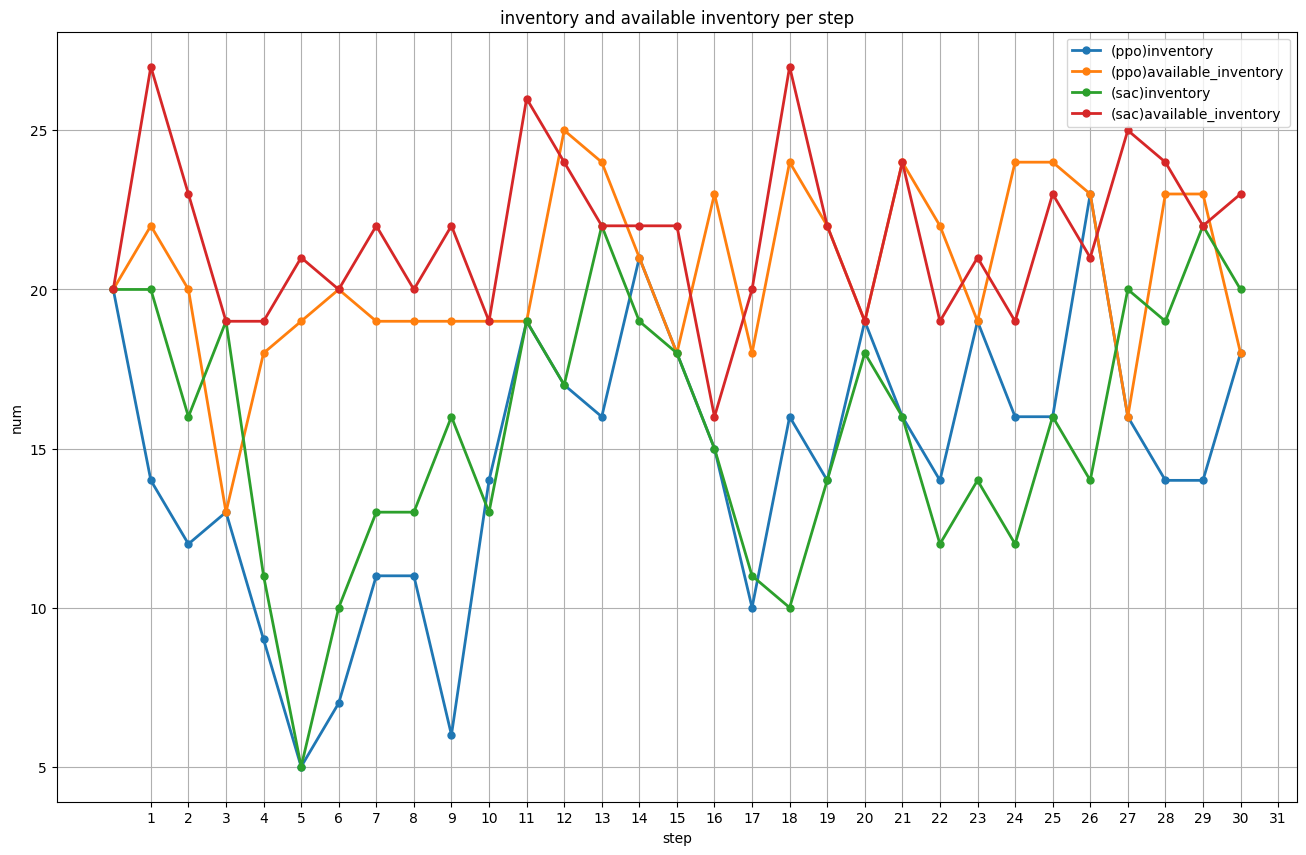

In [ ]:
inventory_list_ppo, available_inventory_list_ppo = inference_timestep(algorithm_name="ppo",
                                                                      env=env_ppo,
                                                                      model=model_ppo,
                                                                      timestep=31)
inventory_list_sac, available_inventory_list_sac = inference_timestep(algorithm_name="sac",
                                                                      env=env_sac,
                                                                      model=model_sac,
                                                                      timestep=31)
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(16, 10))
ax1.plot(np.arange(stop=len(inventory_list_ppo)),
         inventory_list_ppo,
         label="(ppo)inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(available_inventory_list_ppo)),
         available_inventory_list_ppo,
         label="(ppo)available_inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(inventory_list_sac)),
         inventory_list_sac,
         label="(sac)inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(np.arange(stop=len(available_inventory_list_sac)),
         available_inventory_list_sac,
         label="(sac)available_inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.legend(loc=0)
ax1.set_title(label="inventory and available inventory per step")
ax1.set_xlabel(xlabel="step")
ax1.set_ylabel(ylabel="num")
ax1.set_xticks(ticks=np.arange(stop=len(inventory_list_ppo))+1)
ax1.grid(True)
plt.show()